In [10]:
#imports
import pandas as pd
import numpy as np
import pickle as pkl
import os
import time
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA




## **Reading files**

In [11]:
#read \..\..Code\Merged_Data_Preprocessing\Resampled_Data_split\file_structure.pkl

data_path = "../../../../Merged_Data_Preprocessing/Resampled_Data_split"
with open(os.path.join(data_path, 'file_structure.pkl'), 'rb') as f:
    file_structure = pkl.load(f)


#display file structure
file_structure

{'original': {'X_path': 'Resampled_Data_split\\original\\X_original.parquet',
  'y_path': 'Resampled_Data_split\\original\\y_original.pkl'},
 'smote': {'X_path': 'Resampled_Data_split\\smote\\X_smote.parquet',
  'y_path': 'Resampled_Data_split\\smote\\y_smote.pkl'},
 'tomek': {'X_path': 'Resampled_Data_split\\tomek\\X_tomek.parquet',
  'y_path': 'Resampled_Data_split\\tomek\\y_tomek.pkl'},
 'smote_tomek': {'X_path': 'Resampled_Data_split\\smote_tomek\\X_smote_tomek.parquet',
  'y_path': 'Resampled_Data_split\\smote_tomek\\y_smote_tomek.pkl'},
 'test': {'X_path': 'Resampled_Data_split\\test\\X_test.parquet',
  'y_path': 'Resampled_Data_split\\test\\y_test.pkl'},
 'val': {'X_path': 'Resampled_Data_split\\val\\X_val.parquet',
  'y_path': 'Resampled_Data_split\\val\\y_val.pkl'}}

In [12]:
y_train = pd.read_pickle(f'{data_path}/original/y_original.pkl')
y_test = pd.read_pickle(f'{data_path}/test/y_test.pkl')
y_val = pd.read_pickle(f'{data_path}/val/y_val.pkl')

In [13]:
X_test = pd.read_parquet(f'{data_path}/test/X_test.parquet')
X_val = pd.read_parquet(f'{data_path}/val/X_val.parquet')


In [14]:
#loading original no resampled X_train, y_train, X_test, y_test, X_val, y_val parquet files
normalized_path = '../../../../Merged_Data_Preprocessing/Normalized_Data_split'
X_train = pd.read_parquet(f'{normalized_path}/X_train_original.parquet')

In [15]:
# Check data types
X_train.info()

# Convert boolean columns to int
bool_cols = X_train.select_dtypes(include=['bool']).columns
if len(bool_cols) > 0:
    print(f"\nConverting {len(bool_cols)} boolean columns to int...")
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols] = X_test[bool_cols].astype(int)
    X_val[bool_cols] = X_val[bool_cols].astype(int)
    print("Conversion complete!")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16226 entries, 0 to 16225
Data columns (total 64 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   HWSD2_SMU_ID_soil  16226 non-null  int32  
 1   COARSE_soil        16226 non-null  int32  
 2   SAND_soil          16226 non-null  int32  
 3   SILT_soil          16226 non-null  int32  
 4   CLAY_soil          16226 non-null  int32  
 5   BULK_soil          16226 non-null  float64
 6   REF_BULK_soil      16226 non-null  float64
 7   ORG_CARBON_soil    16226 non-null  float64
 8   PH_WATER_soil      16226 non-null  float64
 9   TOTAL_N_soil       16226 non-null  float64
 10  CEC_SOIL_soil      16226 non-null  int32  
 11  CEC_CLAY_soil      16226 non-null  int32  
 12  CEC_EFF_soil       16226 non-null  float64
 13  TEB_soil           16226 non-null  float64
 14  BSAT_soil          16226 non-null  float64
 15  ALUM_SAT_soil      16226 non-null  int32  
 16  ESP_soil           162

## **K Means From Scratch**

In [16]:
class KMeansFromScratch:
    def __init__(self, n_clusters=3, max_iters=100, random_state=42, tol=1e-4):
        """
        K-Means clustering from scratch
        
        Parameters:
        -----------
        n_clusters : int
            Number of clusters
        max_iters : int
            Maximum number of iterations
        random_state : int
            Random seed for reproducibility
        """
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.n_iter_ = None
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.tol = tol
        
    def _euclidean_distance(self, x1, x2):
        """Calculate Euclidean distance between two points"""
        
        # Ensure x2 is reshaped correctly for broadcasting
        if x2.ndim == 1:
            x2 = x2.reshape(1, -1)
        
        # Calculate distance
        return np.sqrt(np.sum((x1 - x2) ** 2, axis=1))
    
    def _initialize_centroids(self, X):
        """Initialize centroids randomly from data points"""
        np.random.seed(self.random_state)
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        centroids = X[random_indices].copy()
        return centroids
    
    def _assign_clusters(self, X):
        """Assign each point to the nearest centroid"""
        distances = np.zeros((X.shape[0], self.n_clusters))
        
        for k in range(self.n_clusters):
            distances[:, k] = self._euclidean_distance(X, self.centroids[k])
        
        return np.argmin(distances, axis=1)
    
    def _update_centroids(self, X, labels):
        """Update centroids as mean of assigned points"""
        centroids = np.zeros((self.n_clusters, X.shape[1]))
        
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                centroids[k] = np.mean(cluster_points, axis=0)
            else:
                # If cluster is empty, reinitialize randomly
                centroids[k] = X[np.random.choice(X.shape[0])]
        
        return centroids
    
    def _calculate_inertia(self, X, labels):
        """Calculate sum of squared distances to nearest centroid"""
        inertia = 0
        for k in range(self.n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                inertia += np.sum((cluster_points - self.centroids[k]) ** 2)
        return inertia
    
    def fit(self, X):
        """
        Fit K-Means to data
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        """
        # Convert to numpy array with float64 dtype
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float64)
        else:
            X = np.asarray(X, dtype=np.float64)
        
        
        # Initialize centroids
        self.centroids = self._initialize_centroids(X)
        self.n_iter_ = 0 

        # Iterate until convergence or max iterations
        for i in range(self.max_iters):
            # Store old centroids
            old_centroids = self.centroids.copy()
            
            # Assign clusters
            labels = self._assign_clusters(X)
            
            # Update centroids
            self.centroids = self._update_centroids(X, labels)
            
            self.n_iter_ = i + 1

            # Check convergence
            shift = np.linalg.norm(self.centroids - old_centroids)
            if shift < self.tol:
                print(f"Converged at iteration {self.n_iter_} with shift={shift:.6f}")
                break

        
        # Store final labels and inertia
        self.labels_ = labels
        self.inertia_ = self._calculate_inertia(X, labels)
        
        return self
    
    def predict(self, X):
        """
        Predict cluster labels for new data
        
        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Data to predict
        """
        if isinstance(X, pd.DataFrame):
            X = X.values.astype(np.float64)
        else:
            X = np.asarray(X, dtype=np.float64)
            
        return self._assign_clusters(X)
    
    def fit_predict(self, X):
        """Fit and predict in one step"""
        self.fit(X)
        return self.labels_

In [17]:
# Test the implementation with your data
start_time = time.time()  # Start timer
print("Training K-Means from scratch...")
print(f"X_train shape: {X_train.shape}")

# Initialize model
kmeans = KMeansFromScratch(n_clusters=5, max_iters=100, random_state=42)

# Fit model
kmeans.fit(X_train)

# Get predictions
train_labels = kmeans.labels_

# Calculate inertia
inertia = kmeans.inertia_
print(f"Inertia: {inertia:.2f}")

# Calculate silhouette score
silhouette = silhouette_score(X_train, train_labels)
print(f"Silhouette Score: {silhouette:.2f}")

# Calculate runtime
runtime = time.time() - start_time
print(f"Runtime: {runtime:.2f} seconds")

print(f"\nResults:")
print(f"Number of iterations: {kmeans.n_iter_}")
print(f"Cluster sizes: {np.bincount(train_labels)}")
print(f"Centroids shape: {kmeans.centroids.shape}")

Training K-Means from scratch...
X_train shape: (16226, 64)
Converged at iteration 26 with shift=0.000000
Inertia: 2317876870.35
Silhouette Score: 0.60
Runtime: 6.98 seconds

Results:
Number of iterations: 26
Cluster sizes: [ 2341  1082 10330   716  1757]
Centroids shape: (5, 64)


## **Visualisation**

d:\DataMining\Fire-Detection-Data-Mining-Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


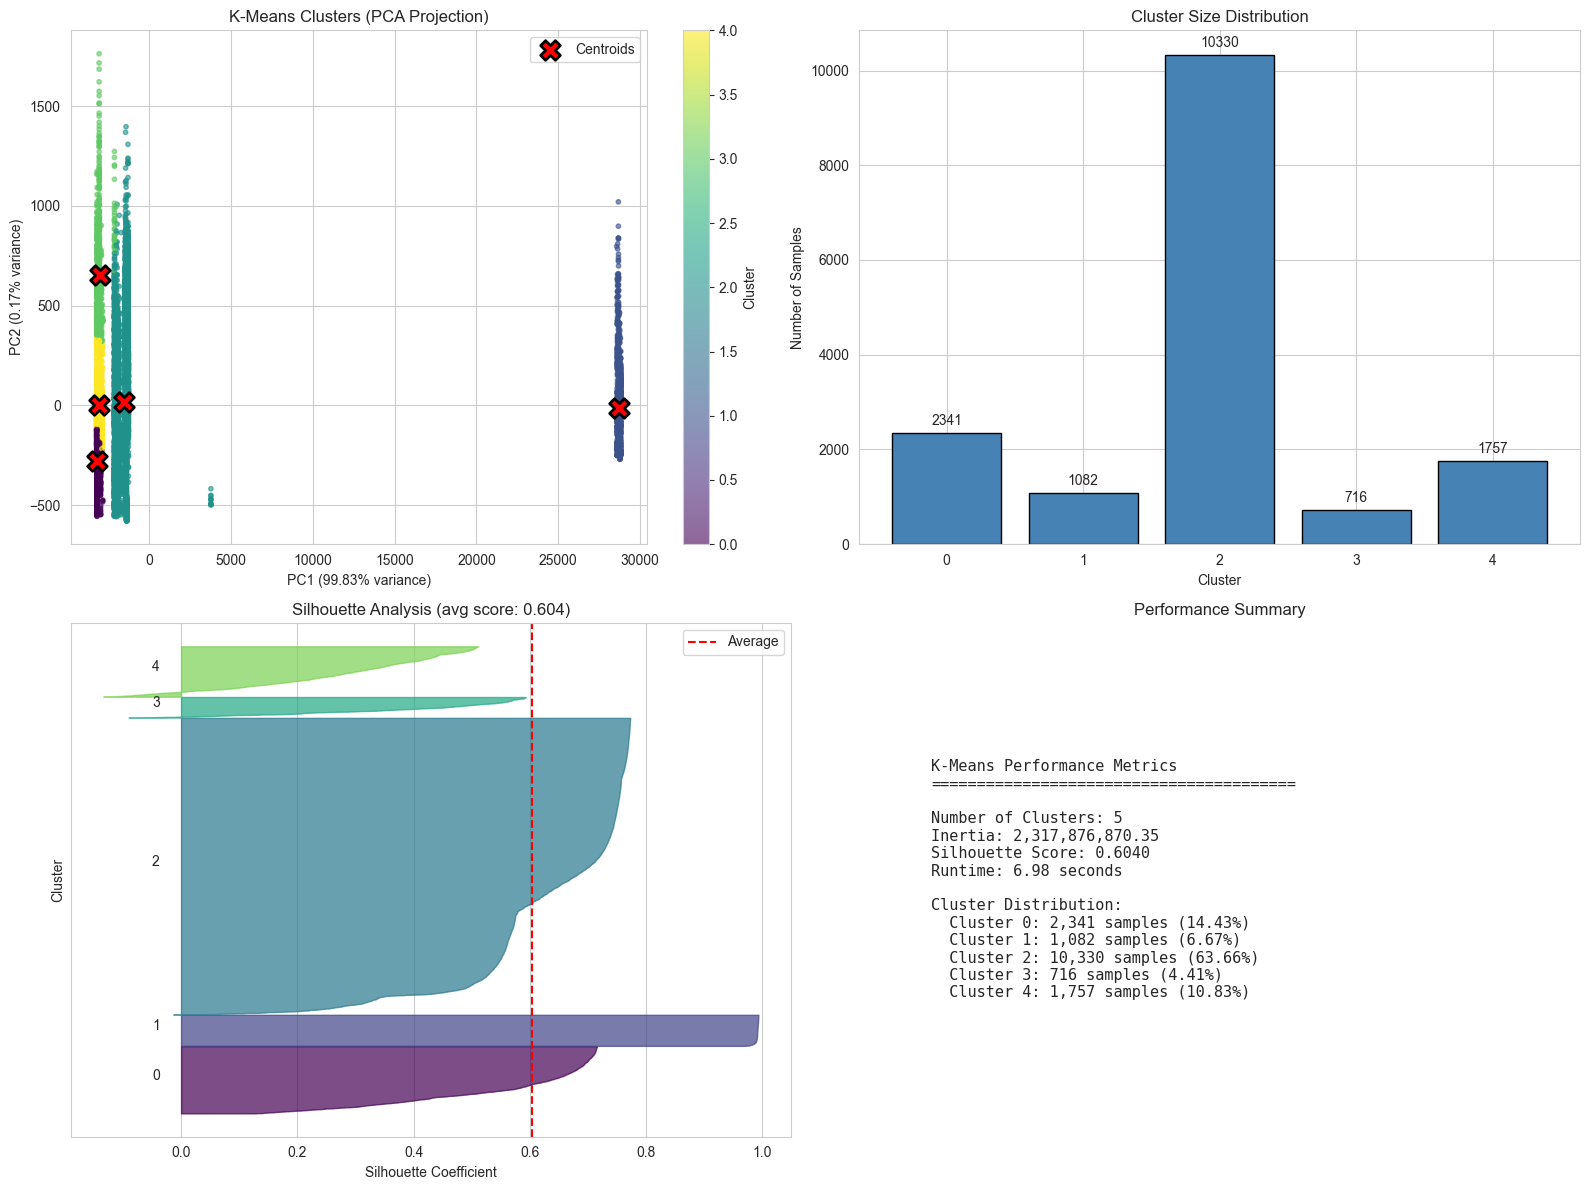


Visualization complete!


In [18]:
# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. PCA visualization of clusters
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

scatter = axes[0, 0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                             c=train_labels, cmap='viridis', alpha=0.6, s=10)
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
axes[0, 0].set_title('K-Means Clusters (PCA Projection)')
plt.colorbar(scatter, ax=axes[0, 0], label='Cluster')

# Plot centroids in PCA space
centroids_pca = pca.transform(kmeans.centroids)
axes[0, 0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
                   c='red', marker='X', s=200, edgecolors='black', linewidths=2,
                   label='Centroids')
axes[0, 0].legend()

# 2. Cluster size distribution
cluster_sizes = np.bincount(train_labels)
axes[0, 1].bar(range(len(cluster_sizes)), cluster_sizes, color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('Cluster')
axes[0, 1].set_ylabel('Number of Samples')
axes[0, 1].set_title('Cluster Size Distribution')
axes[0, 1].set_xticks(range(len(cluster_sizes)))
for i, v in enumerate(cluster_sizes):
    axes[0, 1].text(i, v + max(cluster_sizes)*0.01, str(v), ha='center', va='bottom')

# 3. Silhouette score by cluster
from sklearn.metrics import silhouette_samples
silhouette_vals = silhouette_samples(X_train, train_labels)

y_lower = 10
for i in range(kmeans.n_clusters):
    cluster_silhouette_vals = silhouette_vals[train_labels == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.viridis(float(i) / kmeans.n_clusters)
    axes[1, 0].fill_betweenx(np.arange(y_lower, y_upper),
                              0, cluster_silhouette_vals,
                              facecolor=color, edgecolor=color, alpha=0.7)
    
    axes[1, 0].text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

axes[1, 0].set_xlabel('Silhouette Coefficient')
axes[1, 0].set_ylabel('Cluster')
axes[1, 0].set_title(f'Silhouette Analysis (avg score: {silhouette:.3f})')
axes[1, 0].axvline(x=silhouette, color="red", linestyle="--", label='Average')
axes[1, 0].set_yticks([])
axes[1, 0].legend()

# 4. Summary metrics
metrics_text = f"""
K-Means Performance Metrics
{'='*40}

Number of Clusters: {kmeans.n_clusters}
Inertia: {inertia:,.2f}
Silhouette Score: {silhouette:.4f}
Runtime: {runtime:.2f} seconds

Cluster Distribution:
"""
for i, size in enumerate(cluster_sizes):
    percentage = (size / len(train_labels)) * 100
    metrics_text += f"  Cluster {i}: {size:,} samples ({percentage:.2f}%)\n"

axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
                verticalalignment='center', transform=axes[1, 1].transAxes)
axes[1, 1].axis('off')
axes[1, 1].set_title('Performance Summary')

plt.tight_layout()
plt.savefig('../../../../../Rapport_TP/images/Kmeans/kmeans_visualization_from_scratch.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization complete!")